In [ ]:
!pip install rioxarray

In [ ]:
import rioxarray

In [ ]:
import geopandas as gpd #handles geospatial vector data
import rasterio #reads and writes raster (grid) geospatial data
import shapely #performs geometric operations on shapes
import matplotlib.pyplot as plt #for plots(for some others, we use seaborn)
import geemap #Interactive mapping and analysis with Google Earth Engine
import torch #Deep learning framework for tensor computations
import torchvision #Computer vision tools and pretrained models for PyTorch
import seaborn
import sklearn #we need to install scikit-learn



In [ ]:
!pip install -q kaggle

import json
import os

kaggle_json = {
    "username": "sarathsai...", #provide username here (change the username also)
    "key": "KGAT_4c1117..." #provide api token from https://www.kaggle.com/settings , scroll down to api section, give some random name, copy paste url of the oken
}

os.makedirs("/root/.kaggle", exist_ok=True)#using this, we make sure folder exists
with open("/root/.kaggle/kaggle.json", "w") as f:# save kaggle.json
    json.dump(kaggle_json, f)

!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d rishabhsnip/earth-observation-delhi-airshed #download the dataset
!unzip -o earth-observation-delhi-airshed.zip -d ./dataset #unzip here

In [ ]:
import os

os.listdir("./dataset") #list out all of the directories and .geojson

['worldcover_bbox_delhi_ncr_2021.tif',
 'delhi_airshed.geojson',
 'rgb',
 'delhi_ncr_region.geojson']

In [ ]:
DATA_DIR = "./dataset/rgb"  # sentinel images folder here
NCR_FILE = "./dataset/delhi_ncr_region.geojson"
AIRSHED_FILE = "./dataset/delhi_airshed.geojson"
RASTER_FILE = "./dataset/worldcover_bbox_delhi_ncr_2021.tif"

Done :)


# **Q1. Spatial Reasoning & Data Filtering**

GeoJSON files loaded
NCR CRS: EPSG:4326
Raster loaded
Raster CRS: EPSG:4326
CRS matched
Raster clipped


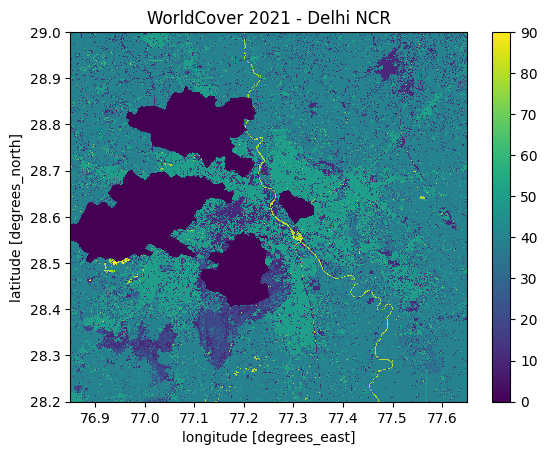

 Everything executed successfully!


In [ ]:
delhi_ncr = gpd.read_file(NCR_FILE)
airshed = gpd.read_file(AIRSHED_FILE)
print("NCR CRS:", delhi_ncr.crs)

raster = rioxarray.open_rasterio(RASTER_FILE)
print("Raster CRS:", raster.rio.crs)

delhi_ncr = delhi_ncr.to_crs(raster.rio.crs)
airshed = airshed.to_crs(raster.rio.crs)
clipped = raster.rio.clip(delhi_ncr.geometry, delhi_ncr.crs, drop=True)

plt.figure()
clipped.plot()
plt.title("Delhi NCR")
plt.show()

Total grid cells before filtering: 35


/tmp/ipython-input-5044/1967497699.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_filtered = grid[grid.intersects(delhi_ncr_utm.unary_union)] # filter grid cells intersecting NCR


Total grid cells after filtering: 29


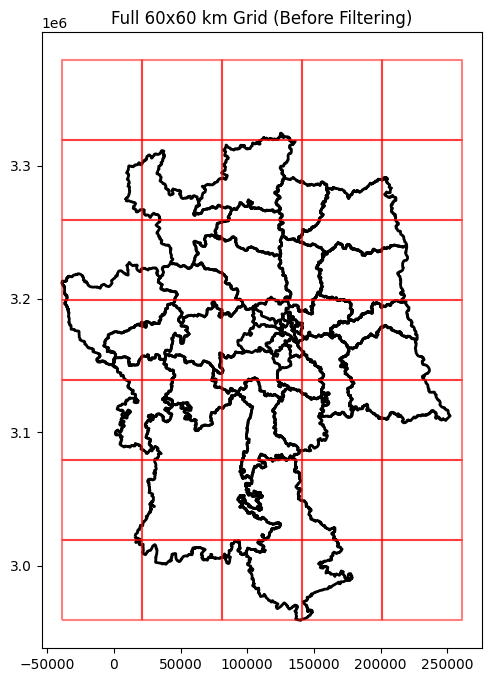

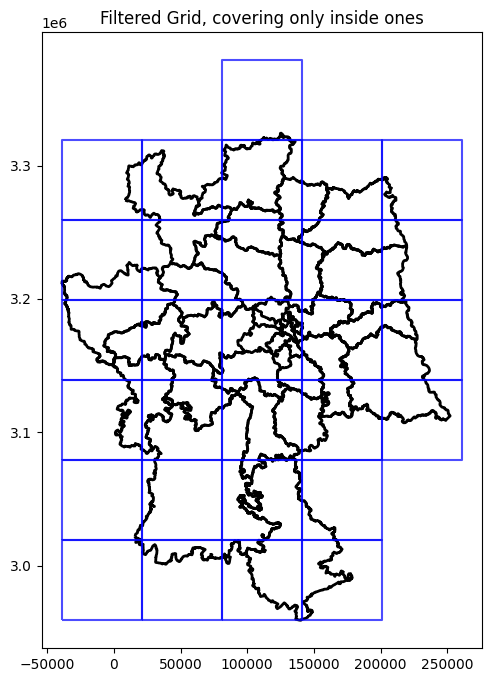

In [ ]:
import numpy as np
from shapely.geometry import box

delhi_ncr_utm = delhi_ncr.to_crs("EPSG:32644") # Convert to EPSG:32644 (UTM zone 44N)
minx, miny, maxx, maxy = delhi_ncr_utm.total_bounds

grid_size = 60000  # 60 km (used later for 60 x 60kms)
grid_cells = []

x_coords = np.arange(minx, maxx, grid_size)
y_coords = np.arange(miny, maxy, grid_size)

for x in x_coords:
    for y in y_coords:
        cell = box(x, y, x + grid_size, y + grid_size)
        grid_cells.append(cell)

grid = gpd.GeoDataFrame(grid_cells, columns=["geometry"], crs="EPSG:32644") # Create full grid (before filtering)
print("Total grid cells before filtering:", len(grid))
grid_filtered = grid[grid.intersects(delhi_ncr_utm.unary_union)] # filter grid cells which intersect NCR
print("Total grid cells after filtering:", len(grid_filtered))


fig, ax = plt.subplots(figsize=(8,8))
delhi_ncr_utm.boundary.plot(ax=ax, color='black', linewidth=2)# plot NCR boundary
grid.boundary.plot(ax=ax, color='red', alpha=0.5)# plot FULL grid (before filtering)
plt.title("Full 60x60 km Grid (Before Filtering)")
plt.show()


fig, ax = plt.subplots(figsize=(8,8))
delhi_ncr_utm.boundary.plot(ax=ax, color='black', linewidth=2)# plot NCR boundary
grid_filtered.boundary.plot(ax=ax, color='blue', alpha=0.7)# plot FILTERED grid
plt.title("Filtered Grid, covering only inside ones")
plt.show()

In [ ]:
from shapely.geometry import Point

image_files = os.listdir(DATA_DIR)


points = []
names = []

for file in image_files:
    if file.endswith(".png"):#because filename formats are like lat_lon.png

        lat, lon = file.replace(".png","").split("_")
        lat, lon = float(lat), float(lon)
        point = Point(lon, lat)  # IMPORTANT: (lon, lat)
        points.append(point)
        names.append(file)

# Create GeoDataFrame in WGS84 first
images_gdf = gpd.GeoDataFrame(
    {"filename": names},
    geometry=points,
    crs="EPSG:4326"
)

print("Total images before filtering:", len(images_gdf))

# Convert images to UTM (same as grid)
images_gdf_utm = images_gdf.to_crs("EPSG:32644")

# Make sure NCR is also in UTM
delhi_ncr_utm = delhi_ncr.to_crs("EPSG:32644")

# Spatial filter
filtered_images = gpd.sjoin(
    images_gdf_utm,
    delhi_ncr_utm,
    predicate="within"
)

print("Total images after filtering:", len(filtered_images))

Total images before filtering: 9216
Total images after filtering: 8015


An example image that was REMOVED: 28.5355_76.8943.png
An example image that was KEPT: 28.4057_77.3734.png


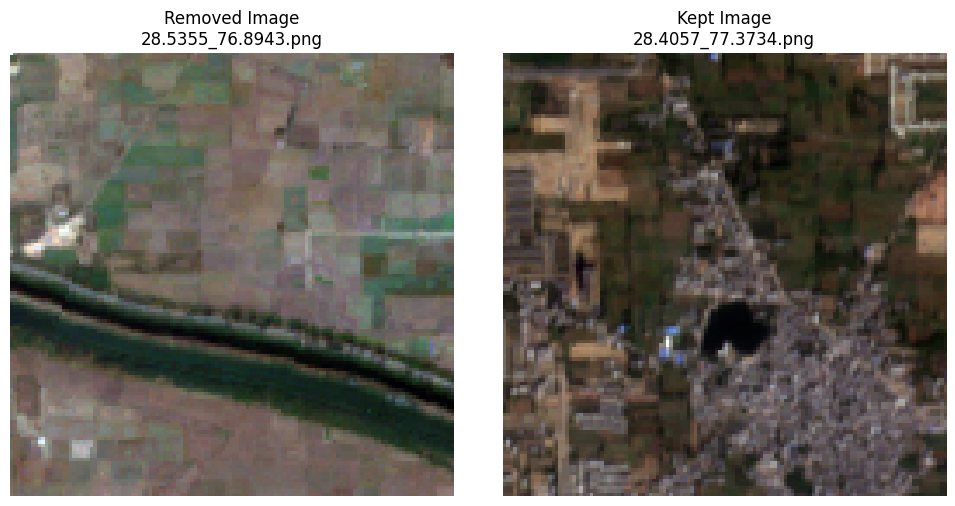

In [ ]:
import matplotlib.image as mpimg

removed_files = set(images_gdf_utm["filename"]) - set(filtered_images["filename"])
removed_example = list(removed_files)[0] #1st image(removed), you can do check for other images
print("An example image that was REMOVED:", removed_example)


kept_files = set(images_gdf_utm["filename"]) & set(filtered_images["filename"])# images kept (inside NCR)
kept_example = list(kept_files)[0]  # pick one example
print("An example image that was KEPT:", kept_example)

removed_path = os.path.join(DATA_DIR, removed_example)# image paths(will be joined wth DATA_DIRECTORY(existing))
kept_path = os.path.join(DATA_DIR, kept_example)


removed_img = mpimg.imread(removed_path) # load images
kept_img = mpimg.imread(kept_path)


fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(removed_img)# removed because it is outside the grid(you change grid size, the no of images that should be filtered willnot change)
axes[0].set_title(f"Removed Image\n{removed_example}")# removed image
axes[0].axis('off')

axes[1].imshow(kept_img)
axes[1].set_title(f"Kept Image\n{kept_example}")# kept image
axes[1].axis('off')

plt.tight_layout()# plot side by side with subplots
plt.show()

# **Q2. Label Construction & Dataset Preparation**

In [ ]:
from scipy.stats import mode #we do have rioxarray previously, so we ignore it

filtered_images = filtered_images.to_crs(raster.rio.crs)

In [ ]:
def extract_patch_safe(raster, x, y, patch_size=128, debug=False):
    import numpy as np
    from rasterio.transform import rowcol

    minx, miny, maxx, maxy = raster.rio.bounds()

    if not (minx <= x <= maxx and miny <= y <= maxy):
        if debug:
            print("Point outside bounds:", x, y)
        return None

    transform = raster.rio.transform()
    row, col = rowcol(transform, x, y)

    height = raster.rio.height
    width = raster.rio.width

    if row < 0 or col < 0 or row >= height or col >= width:
        if debug:
            print("Invalid pixel index:", row, col)
        return None

    half = patch_size // 2

    row_start = max(row - half, 0)
    row_end   = min(row + half, height)
    col_start = max(col - half, 0)
    col_end   = min(col + half, width)

    data = raster.values

    if data.ndim == 3:
        patch = data[0, row_start:row_end, col_start:col_end]
    else:
        patch = data[row_start:row_end, col_start:col_end]

    if patch.size == 0:
        if debug:
            print("Empty patch after slicing")
        return None

    if debug:
        print("Point:", x, y)
        print("Row/Col:", row, col)
        print("Patch shape:", patch.shape)
        print("-----")

    return patch

In [ ]:
print(raster.shape)
print(raster.dims)

(1, 9600, 9602)
('band', 'y', 'x')


In [ ]:
import numpy as np
from scipy.stats import mode

filtered_images = filtered_images.to_crs(raster.rio.crs)

for idx, row in filtered_images.iterrows():
    x = row.geometry.x
    y = row.geometry.y

    patch = extract_patch_safe(raster, x, y, patch_size=128)

    if patch is None:
        print("Warning: empty patch for index", idx)
        continue

    m = mode(patch, axis=None, keepdims=False)
    dominant_class = m.mode if np.isscalar(m.mode) else m.mode[0]

    print("Dominant class:", dominant_class)

In [ ]:
from sklearn.model_selection import train_test_split
esa_to_category = {
    10: "Vegetation",      # Tree cover
    20: "Vegetation",      # Shrubland
    30: "Vegetation",      # Grassland
    40: "Cropland",
    50: "Built-up",
    #60: "Bare", =0
    #70: "Snow/Ice", =0
    80: "Water",
    90: "Wetland",
    #95: "Mangroves", =0
    #100: "Moss/Lichen" =0
}

filtered_images["land_use"] = filtered_images["esa_class"].map(esa_to_category) #total cleaning
filtered_images_clean = filtered_images.dropna(subset=["land_use"])
print("Total images after cleaning:", len(filtered_images_clean))

train_df, test_df = train_test_split( #test size = 0.4
    filtered_images_clean,
    test_size=0.4,
    stratify=filtered_images_clean["land_use"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nClass distribution:")
print(filtered_images_clean["land_use"].value_counts())

Total images after cleaning: 8015
Train size: 4809
Test size: 3206

Class distribution:
land_use
Cropland      5474
Built-up      1778
Vegetation     754
Water            7
Wetland          2
Name: count, dtype: int64


# **Q3. Model Training & Supervised Evaluation**

Using device: cpu
Classes: ['Built-up', 'Cropland', 'Vegetation', 'Water', 'Wetland']
Epoch [1/5], Loss: 0.6493
Epoch [2/5], Loss: 0.5114
Epoch [3/5], Loss: 0.4893
Epoch [4/5], Loss: 0.4328
Epoch [5/5], Loss: 0.3625

Test Accuracy: 0.8184653774173425
Test F1-score: 0.802977832608336


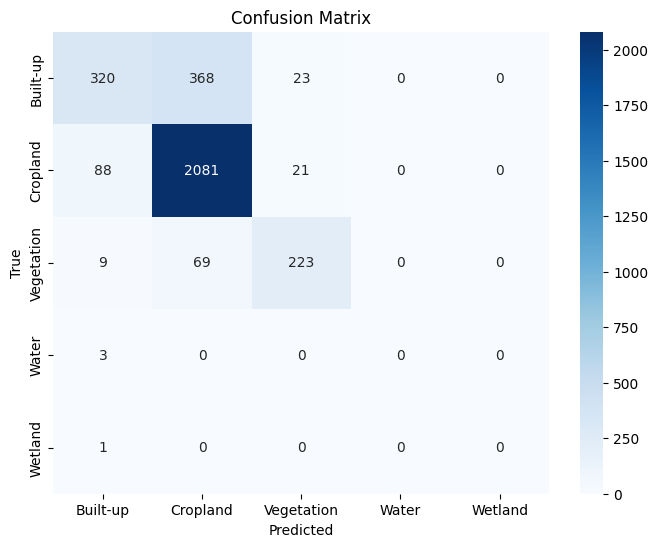

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
classes = sorted(train_df["land_use"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
print("Classes:", classes)

class LandUseDataset(Dataset):
    def __init__(self, dataframe, raster):
        self.df = dataframe.reset_index(drop=True)
        self.raster = raster

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x, y = row.geometry.x, row.geometry.y

        patch = extract_patch_safe(self.raster, x, y, patch_size=128)
        if patch is None:
            patch = np.zeros((128,128), dtype=np.float32)
        patch = patch.astype(np.float32)
        patch = patch / patch.max() if patch.max() != 0 else patch #convert to 3 channels(RGB)
        patch = np.stack([patch]*3, axis=0)

        label = class_to_idx[row["land_use"]]

        return torch.tensor(patch), torch.tensor(label)
train_dataset = LandUseDataset(train_df, raster)
test_dataset = LandUseDataset(test_df, raster)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class TinyCNN(nn.Module):
    def __init__(self, num_classes):
        super(TinyCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = TinyCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for img, lbls in train_loader:
        img, lbls = img.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(img)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for img, lbl in test_loader:
        img = img.to(device)
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\nTest Accuracy:", accuracy)
print("Test F1-score:", f1)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Using device: cpu
Classes: ['Built-up', 'Cropland', 'Vegetation', 'Water', 'Wetland']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


Epoch [1/5], Loss: 0.4609
Epoch [2/5], Loss: 0.1301
Epoch [3/5], Loss: 0.0552
Epoch [4/5], Loss: 0.0451
Epoch [5/5], Loss: 0.0274

Test Accuracy: 0.916406737367436
Test F1-score: 0.9153091651160522


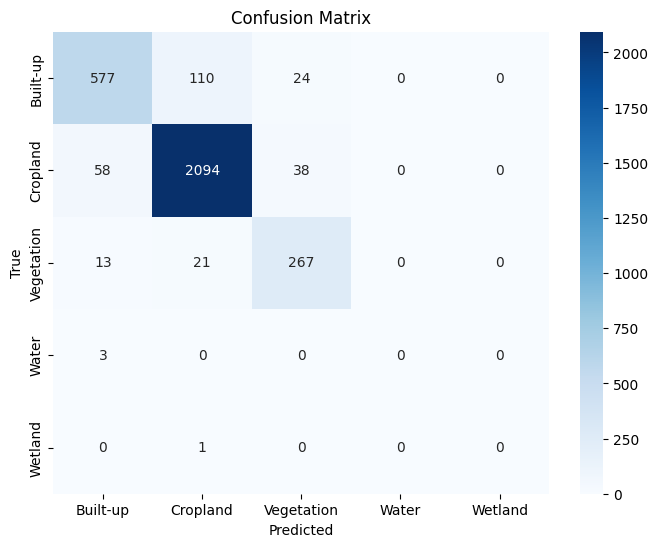

In [ ]:
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

classes = sorted(train_df["land_use"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print("Classes:", classes)

class LandUseDataset(Dataset):
    def __init__(self, dataframe, raster):
        self.df = dataframe.reset_index(drop=True)
        self.raster = raster

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x, y = row.geometry.x, row.geometry.y

        patch = extract_patch_safe(self.raster, x, y, patch_size=128)

        if patch is None:
            patch = np.zeros((128, 128))
        patch = patch.astype(np.float32)
        patch = patch / patch.max() if patch.max() != 0 else patch
        patch = np.stack([patch]*3, axis=0)

        label = class_to_idx[row["land_use"]]

        return torch.tensor(patch), torch.tensor(label)

train_dataset = LandUseDataset(train_df, raster)
test_dataset = LandUseDataset(test_df, raster)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\nTest Accuracy:", accuracy)
print("Test F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


The first one I completed entirely on my own, achieving **81**% accuracy and an **81**% F1-score.

For the second one, I achieved **91**% accuracy and F1-score. I initially tried using AlexNet and znet (I initially tried using AlexNet and ZNet, as we have covered them in our coursework, but since ResNet was required), I honestly did my best to work with it. I ran into several errors, so I sought a bit of guidance to understand ResNet. And now, I fully understand how it works.